## Stable Differentiable Causal Discovery (SDCD) Tutorial

In this brief tutorial, we will go over the main API for the `sdcd` package. SDCD is a differentiable causal discovery method designed to scale reliably to hundreds and thousands of variables. The algorithm is implemented in vanilla PyTorch and also uses the `networkx` package. 

(Note, under the default pip installation, only the packages necessary to run the `SDCD` model are installed. If you would also like to run other causal discovery methods implemented in this package, you must also install the `benchmark` extra via the `pip install sdcd[benchmark]` command.)

In [20]:
# Imports
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/sdcd')
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/dagma/src/')
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_discovery/notears')
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/')
from sdcd.models import SDCD
from sdcd.utils import create_intervention_dataset
from dagma.locally_connected import LocallyConnected
import torch
import torch.nn as nn
import numpy as np
from  torch import optim
import copy
from pathlib import Path
from tqdm.auto import tqdm
import typing
import notears
import math
from edit_modules.load_datasets_morphominist import _get_paths,load_idx
from edit_modules.load_datasets_adni import load_data,load_extra_attributes,ordinal_array
from edit_modules.load_datasets_adni import unnormalize as adni_unormalize
from edit_modules.load_datasets_adni import normalize as adni_normalize
from edit_modules.TI_datasets_discovery import bin_array

We will start by simulating some data for the tutorial. If you have your own data, you can ignore this step.

# causal discovery

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
def zscore_continu_minmax_categorical(attr_df,z_score_columns,min_max_columns):
    # Apply Z-score normalization
    scaler_z = StandardScaler()
    attr_df[z_score_columns] = scaler_z.fit_transform(attr_df[z_score_columns])

    # Apply Min-Max normalization (scaled to range [0,1])
    scaler_minmax = MinMaxScaler()
    attr_df[min_max_columns] = scaler_minmax.fit_transform(attr_df[min_max_columns])

    # Transform Min-Max normalized data to range [-1,1]
    #attr_df[min_max_columns] = attr_df[min_max_columns] * 2 - 1
    return attr_df

In [22]:
import os 
import numpy as np
from torchvision.datasets import CelebA
import pandas as pd

dataset = 'pendulum'
if dataset == 'pendulum':
    #data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_4_concepts/pendulum/3/'
    data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data2/pendulum/train/'
    image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
    adj_matrix=np.array([[0, 0, 1, 1], [0, 0, 1, 1], [0, 0, 0, 0], [0, 0, 0, 0]])
    imglabel =np.array([list(map(float, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths])
    # Gaussian normalizaton scales
    scale = np.array([[2,42],[104,44],[7.5, 4.5],[11,8]])
    #scale = np.array([[2,42],[104,44],[7.5, 4.5],[11,8]])
    # Compute min and max for each label column
    # min_vals = imglabel.min(axis=0)  # Min value per column
    # max_vals = imglabel.max(axis=0)  # Max value per column
elif 'celeA' in dataset:
    data_dir = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/"
    data = CelebA(root=data_dir, split='train', transform=None, download=False)
    if 'simple' in dataset:
        selected_item = ['Smiling','Eyeglasses']
    
    elif 'complex' in dataset:
        selected_item = ['Young','Male','No_Beard','Bald']

    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel = np.asarray(attrs)
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}

elif dataset == 'MorphoMNIST':
    data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/datasets/morphomnist/data/'
    images_path, labels_path, metrics_path = _get_paths(data_root,train=True)
    
    # digits 10 numbers
    labels = load_idx(labels_path)
    # for thickness and intensity
    metric = pd.read_csv(metrics_path, index_col='index')

    #metric[['thickness', 'intensity']] = (metric[['thickness', 'intensity']] - metric[['thickness', 'intensity']].mean()) / metric[['thickness', 'intensity']].std()

    # Concatenate normalized metrics with labels
    metric['label'] = labels
    z_score_columns = ['thickness', 'intensity']
    min_max_columns = ['label']

    df_transformed = zscore_continu_minmax_categorical(metric,z_score_columns,min_max_columns)


    # # Convert thickness and intensity to tensor
    # df_normalized = (metric - metric.min()) / (metric.max() - metric.min())
    # # Step 2: Transform to [-1, 1]
    # df_transformed = df_normalized * 2 - 1
    imglabel = np.asarray(df_transformed.values)
    



elif dataset == 'ADNI':
    data_root = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/ctf_datasets/adni/preprocessing"
    num_of_slices = 10
    keep_only_screening = False
    data_dir = os.path.join(data_root, 'preprocessed_data')
    image_paths, attribute_dict, subject_dates_dict = load_data(data_dir, num_of_slices=num_of_slices,
                                                            split='train',
                                                            keep_only_screening=keep_only_screening)
    csv_path = list(Path(data_root).glob('ADNIMERGE*.csv'))[0]
    assert csv_path.is_file(), "Provide ADNIMERGE csv path"
    attribute_size={
            "apoE": 2,
            "age": 1,
            "sex": 1,
            "brain_vol": 1,
            "vent_vol": 1,
            "slice": 10
        }
    attributes, indices_to_remove = load_extra_attributes(csv_path, attributes=attribute_size.keys(),
                                                                    attribute_dict=attribute_dict, subject_dates_dict=subject_dates_dict,
                                                                    keep_only_screening=keep_only_screening)
                                                                   
    attributes['slice'] = np.delete(attributes['slice'], indices_to_remove, axis=0)
    '''min-max normalize for all of features'''
    attributes = {attr: adni_normalize(torch.tensor(np.array(values), dtype=torch.float32), attr) for attr, values in attributes.items()}
    attributes['slice'] = ordinal_array(torch.from_numpy(np.array(attributes['slice'])),reverse=True)
    attributes['apoE'] = bin_array(torch.from_numpy(np.array(attributes['apoE'])),reverse=True)
    attrs = torch.cat([attributes[attr].unsqueeze(1) if len(attributes[attr].shape) == 1 else attributes[attr]
                                for attr in attribute_size.keys()], dim=1)
                
    
    imglabel = np.array(attrs)
    

# Min-Max normalization function
def normalize_label_minmax(label, min_vals, max_vals):
    """
    Apply Min-Max normalization to bring values to range (-1, 1).
    Formula: norm_label = ((value - min) / (max - min)) * 2 - 1
    """
    norm_label = ((label - min_vals) / (max_vals - min_vals)) * 2 - 1
    return norm_label.astype(np.float32)

def normalize_label(label):
    norm_label = np.zeros(label.shape)        
    for i in range(4):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    return norm_label
if dataset in ['pendulum']:
    #imglabel = np.apply_along_axis(normalize_label_minmax, 1, imglabel, min_vals, max_vals)
    imglabel = np.apply_along_axis(normalize_label, 1, imglabel)
else:
    pass

print(imglabel.shape)

(5482, 4)


In [23]:
imglabel[:10]

array([[-1.        , -1.        , -1.        , -1.12399598],
       [-1.        , -0.97727273, -1.        , -1.10276535],
       [-1.        , -0.95454545, -1.        , -1.0819984 ],
       [-1.        , -0.93181818, -1.        , -1.06167018],
       [-1.        , -0.88636364, -1.        , -1.02223737],
       [-1.        , -0.86363636, -1.        , -1.00308976],
       [-1.        , -0.84090909, -1.        , -0.98429465],
       [-1.        , -0.79545455, -1.        , -0.94768825],
       [-1.        , -0.77272727, -1.        , -0.92984248],
       [-1.        , -0.75      , -1.        , -0.91228012]])

In [24]:
# Calculate the mean and standard deviation for each column
data = np.array(imglabel)
mean_per_column = np.mean(data, axis=0)
std_per_column = np.std(data, axis=0)

print("Mean of each column:", mean_per_column)
print("Standard deviation of each column:", std_per_column)

Mean of each column: [-0.01194819 -0.01062983 -0.56204088 -0.05724131]
Standard deviation of each column: [0.57741282 0.5806589  0.52610242 0.42856961]


In [25]:
import pandas as pd
method_name = 'SDCD'

if method_name == 'SDCD':
    torch.set_default_dtype(torch.float)
    df = pd.DataFrame(data=data,columns=list(range(data.shape[1])))
    df['perturbation_label']='obs'
    X_dataset = create_intervention_dataset(df, perturbation_colname="perturbation_label")
    model = SDCD()
    model.train(X_dataset, finetune=True,device='cpu')
    adj_matrix_unthreshold = model.get_adjacency_matrix(threshold=False)
    adj_matrix_threshold = model.get_adjacency_matrix(threshold=True)

elif method_name == 'notears':
    torch.set_default_dtype(torch.double)
    np.set_printoptions(precision=3)

    import notears.utils as ut
    ut.set_random_seed(123)
    
    data = data.astype(np.double)
    from notears.nonlinear import NotearsMLP,notears_nonlinear
    d= data.shape[1]
    model = NotearsMLP(dims=[d, 10, 1], bias=True)
    adj_matrix_threshold,adj_matrix_unthreshold = notears_nonlinear(model, data, lambda1=0.01, lambda2=0.01)
    # from notears.linear import notears_linear
    # W_est = notears_linear(data, lambda1=0.1, loss_type='l2')
    

elif method_name == 'dagma':
    # Threshold is 1 
    from timeit import default_timer as timer
    from dagma import utils
    from dagma.nonlinear import DagmaMLP,DagmaNonlinear

    utils.set_random_seed(123)
    torch.manual_seed(123)

    d= data.shape[1]
    eq_model = DagmaMLP(dims=[d, 10, 1], bias=True)
    model = DagmaNonlinear(eq_model)
    adj_matrix_threshold,adj_matrix_unthreshold = model.fit(data, lambda1=0.02, lambda2=0.005)
    


0
Epoch 0: loss=3.90, gamma=0.00


KeyboardInterrupt: 

In [33]:
# fine-tune SDCD
import pandas as pd
method_name = 'SDCD'

if method_name == 'SDCD':
    torch.set_default_dtype(torch.float)
    df = pd.DataFrame(data=data,columns=list(range(data.shape[1])))
    df['perturbation_label']='obs'
    X_dataset = create_intervention_dataset(df, perturbation_colname="perturbation_label")
    model = SDCD(model_variance_flavor='unit')
    model.fine_tune(X_dataset, finetune=True,device='cpu',_final_mask = adj_matrix)
    # adj_matrix_unthreshold = model.get_adjacency_matrix(threshold=False)
    # adj_matrix_threshold = model.get_adjacency_matrix(threshold=True)

    


0
Fixing adjacency matrix.
Beginning finetune.
Epoch 0: loss=4.38, gamma=0.00
Epoch 100: loss=4.18, gamma=0.00
Epoch 200: loss=4.19, gamma=0.00
Epoch 300: loss=4.19, gamma=0.00
Epoch 400: loss=4.18, gamma=0.00
Epoch 500: loss=4.19, gamma=0.00
Early stopping triggered.


In [27]:
model._model.get_adjacency_matrix()

tensor([[0.0000, 0.0000, 3.4999, 0.9146],
        [0.0000, 0.0000, 4.4110, 1.5137],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000]], grad_fn=<LinalgVectorNormBackward0>)

In [11]:
torch.from_numpy(data[1]).unsqueeze(0).dtype

torch.float64

In [32]:
print(data[1])
x_mean, x_var = model._model(torch.from_numpy(data[1]).unsqueeze(0).float())
print(x_mean, x_var)
print(x_mean+x_var)
x_sample = x_mean + torch.randn_like(x_mean) * x_var.sqrt()
print(x_sample)

[-1.         -0.97727273 -1.         -1.10276535]
tensor([[-0.0147, -0.0144, -1.0091, -1.0266]], grad_fn=<SqueezeBackward1>) tensor([[0.3379, 0.3375, 0.0029, 0.0004]], grad_fn=<SqueezeBackward1>)
tensor([[ 0.3232,  0.3230, -1.0062, -1.0262]], grad_fn=<AddBackward0>)
tensor([[-0.9513, -1.6385, -1.0276, -1.0188]], grad_fn=<AddBackward0>)


In [31]:
end_index = 10
print(data[100:105])
x_mean, x_var = model._model(torch.from_numpy(data[100:105]).float())
print('prediction',(x_mean+x_var).detach().numpy())
print(x_mean.detach().numpy())

x_sample = x_mean + torch.randn_like(x_mean) * x_var.sqrt()
print(x_sample)

[[-0.97619048  0.06818182 -0.26208149 -0.36823817]
 [-0.97619048  0.09090909 -0.23456996 -0.3540743 ]
 [-0.97619048  0.11363636 -0.20694902 -0.33985411]
 [-0.97619048  0.15909091 -0.15132117 -0.31121501]
 [-0.97619048  0.18181818 -0.12328472 -0.29678089]]
prediction [[ 0.3231575   0.32303804 -0.25462034 -0.38329735]
 [ 0.3231575   0.32303804 -0.21556662 -0.36883244]
 [ 0.3231575   0.32303804 -0.17616315 -0.35434532]
 [ 0.3231575   0.32303804 -0.09666002 -0.3253052 ]
 [ 0.3231575   0.32303804 -0.05674    -0.3107531 ]]
[[-0.01474625 -0.01443381 -0.25940537 -0.38390696]
 [-0.01474625 -0.01443381 -0.22047126 -0.36944842]
 [-0.01474625 -0.01443381 -0.18119144 -0.35496783]
 [-0.01474625 -0.01443381 -0.10194719 -0.3259411 ]
 [-0.01474625 -0.01443381 -0.06216204 -0.31139588]]
tensor([[ 0.3234, -0.0128, -0.2334, -0.3745],
        [-0.0096, -0.2951, -0.2183, -0.3842],
        [-0.0887,  0.0890, -0.1321, -0.3212],
        [ 0.1982, -0.4124, -0.1527, -0.3534],
        [-0.2004,  0.8944, -0.1234, -

In [73]:
adj_matrix_unthreshold

array([[0.000e+00, 1.252e+00, 1.101e-04, 1.840e-04],
       [1.088e+00, 0.000e+00, 0.000e+00, 7.064e-04],
       [1.959e+00, 2.302e+00, 0.000e+00, 1.197e+00],
       [1.972e+00, 1.501e+00, 1.006e-03, 0.000e+00]], dtype=float32)

In [74]:
import os
save_path_threshold = './saved_mtx/{}_causaldata2/{}_threshold.csv'.format(dataset,method_name)
save_path = './saved_mtx/{}_causaldata2/{}.csv'.format(dataset,method_name)
dir_path = os.path.dirname(save_path)  # Extract the directory path
os.makedirs(dir_path, exist_ok=True)

np.savetxt(save_path_threshold, adj_matrix_threshold, delimiter=',')
np.savetxt(save_path, adj_matrix_unthreshold, delimiter=',')
print(save_path)

./saved_mtx/pendulum_causaldata2/SDCD.csv


Lastly, we can recover the predicted adjacency matrix, both before thresholding and after thresholding, and compute likelihoods respect to a given observation.

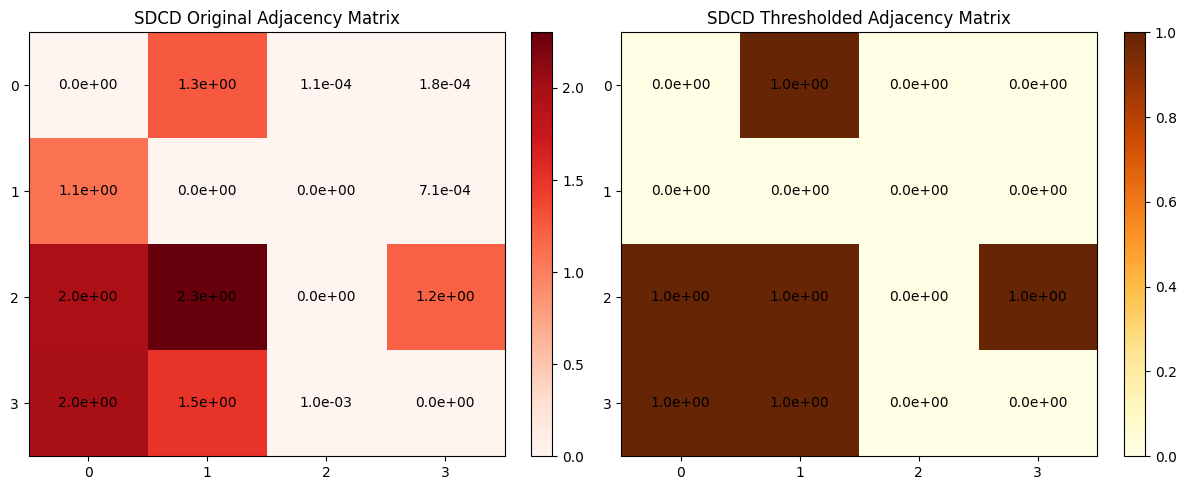

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import os
load_dataset = 'pendulum_causaldata2'
method_name = 'SDCD'
root_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/notebooks/saved_mtx/'

adj_matrix = np.loadtxt(os.path.join(root_path,load_dataset,method_name+'.csv'),delimiter=",") 
thresholded_matrix = np.loadtxt(os.path.join(root_path,load_dataset,method_name+'_threshold.csv'),delimiter=",") 
# Function to visualize adjacency matrix


def visualize_adjacency_matrices(original, thresholded):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    matrices = [original, thresholded]
    titles = ["{} Original Adjacency Matrix".format(method_name), "{} Thresholded Adjacency Matrix".format(method_name)]

    for i, ax, matrix, title in zip([0,1],axes, matrices, titles):
        vmin = np.min(matrix)
        vmax = np.max(matrix)
        if vmin==vmax:
            vmax=1.0 
        if i==0:
            im = ax.imshow(matrix, vmin=vmin,vmax=vmax,cmap="Reds", aspect="auto")
        else:
            im = ax.imshow(matrix,vmin=vmin,vmax=vmax,cmap="YlOrBr", aspect="auto")
        # Add text annotations (show numbers in each cell)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f"{matrix[i, j]:.1e}", ha='center', va='center', color='black')

        # Set labels
        ax.set_xticks(range(matrix.shape[1]))
        ax.set_yticks(range(matrix.shape[0]))
        ax.set_xticklabels(range(matrix.shape[1]))
        ax.set_yticklabels(range(matrix.shape[0]))
        ax.set_title(title)

        # Add a colorbar for each subplot
        fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05)

    plt.tight_layout()
    plt.show()

# Visualize both matrices in subplots
visualize_adjacency_matrices(adj_matrix, thresholded_matrix)


In [64]:
import numpy as np
from scipy.special import expit as sigmoid
import igraph as ig
import random


def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)


def is_dag(W):
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()
def count_accuracy(B_true: np.ndarray, B_est: np.ndarray) -> dict:
    r"""
    Compute various accuracy metrics for B_est.

    | true positive = predicted association exists in condition in correct direction
    | reverse = predicted association exists in condition in opposite direction
    | false positive = predicted association does not exist in condition
    
    Parameters
    ----------
    B_true : np.ndarray
        :math:`[d, d]` ground truth graph, :math:`\{0, 1\}`.
    B_est : np.ndarray
        :math:`[d, d]` estimate, :math:`\{0, 1, -1\}`, -1 is undirected edge in CPDAG.

    Returns
    -------
    dict
        | fdr: (reverse + false positive) / prediction positive
        | tpr: (true positive) / condition positive
        | fpr: (reverse + false positive) / condition negative
        | shd: undirected extra + undirected missing + reverse
        | nnz: prediction positive
    """
    if (B_est == -1).any():  # cpdag
        if not ((B_est == 0) | (B_est == 1) | (B_est == -1)).all():
            raise ValueError('B_est should take value in {0,1,-1}')
        if ((B_est == -1) & (B_est.T == -1)).any():
            raise ValueError('undirected edge should only appear once')
    else:  # dag
        if not ((B_est == 0) | (B_est == 1)).all():
            raise ValueError('B_est should take value in {0,1}')
        if not is_dag(B_est):
            raise ValueError('B_est should be a DAG')
    d = B_true.shape[0]
    # linear index of nonzeros
    pred_und = np.flatnonzero(B_est == -1)
    pred = np.flatnonzero(B_est == 1)
    cond = np.flatnonzero(B_true)
    cond_reversed = np.flatnonzero(B_true.T)
    cond_skeleton = np.concatenate([cond, cond_reversed])
    # true pos
    true_pos = np.intersect1d(pred, cond, assume_unique=True)
    # treat undirected edge favorably
    true_pos_und = np.intersect1d(pred_und, cond_skeleton, assume_unique=True)
    true_pos = np.concatenate([true_pos, true_pos_und])
    # false pos
    false_pos = np.setdiff1d(pred, cond_skeleton, assume_unique=True)
    false_pos_und = np.setdiff1d(pred_und, cond_skeleton, assume_unique=True)
    false_pos = np.concatenate([false_pos, false_pos_und])
    # reverse
    extra = np.setdiff1d(pred, cond, assume_unique=True)
    reverse = np.intersect1d(extra, cond_reversed, assume_unique=True)
    # compute ratio
    pred_size = len(pred) + len(pred_und)
    cond_neg_size = 0.5 * d * (d - 1) - len(cond)
    fdr = float(len(reverse) + len(false_pos)) / max(pred_size, 1)
    tpr = float(len(true_pos)) / max(len(cond), 1)
    fpr = float(len(reverse) + len(false_pos)) / max(cond_neg_size, 1)
    # structural hamming distance
    pred_lower = np.flatnonzero(np.tril(B_est + B_est.T))
    cond_lower = np.flatnonzero(np.tril(B_true + B_true.T))
    extra_lower = np.setdiff1d(pred_lower, cond_lower, assume_unique=True)
    missing_lower = np.setdiff1d(cond_lower, pred_lower, assume_unique=True)
    shd = len(extra_lower) + len(missing_lower) + len(reverse)
    return {'fdr': fdr, 'tpr': tpr, 'fpr': fpr, 'shd': shd, 'nnz': pred_size}

B_true =np.array([[0,0,1.0,1.0],
                   [0,0,1.0,1.0],
                   [0,0,0,0],
                   [0,0,0,0],
                   ])
acc = count_accuracy(B_true, adj_matrix!=0)
print(acc)

{'fdr': 0.3333333333333333, 'tpr': 1.0, 'fpr': 1.0, 'shd': 2, 'nnz': 6}


Is DAG: True


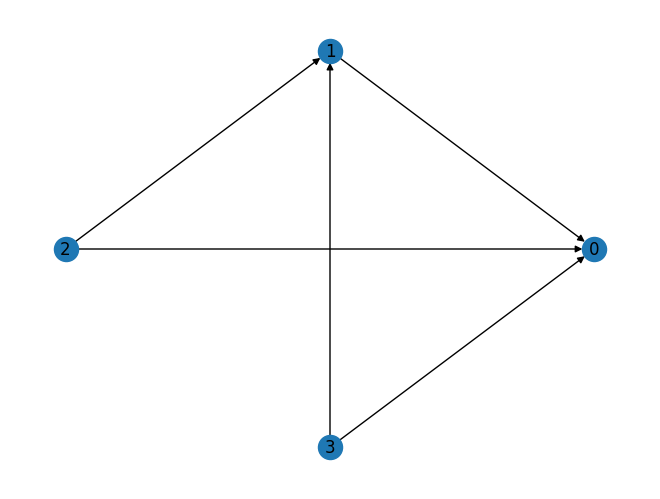

In [70]:
# We can visualize the graph with the networkx package (Note: you will need matplotlib for this step)
import networkx as nx
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph())
print('Is DAG:', nx.is_directed_acyclic_graph(G))
nx.draw_circular(G, with_labels=True)

# Chexpert

In [9]:
import os 
import numpy as np
import pandas as pd
data_root = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_datasets/cheXpert/sampling_100"
#data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/train/'
select_columns = ['Sex', 'Age', 'Pleural Effusion']
dataset_id = data_root.split('/')[-1].split('_')[-1]
root_parent = os.path.dirname(data_root)
csv_path = os.path.join(root_parent,'meta_'+dataset_id+'.csv')
df = pd.read_csv(csv_path)
img_names =np.asarray(df.Path)
image_paths = [os.path.join(data_root, file_path) for file_path in img_names]
label_list = np.asarray(df[select_columns])
mapping = {'Female': 0, 'Male': 1}
# Convert the first column to integers using the mapping
label_list[:, 0] = np.vectorize(mapping.get)(label_list[:, 0])
# Convert the entire array to integer type
label_list = label_list.astype(int)
imglabel =label_list
# this scale for max-min normalization
scale = np.array([[0,1],[20,100],[0, 1]])

def normalize_label_minmax(label):
    norm_label = np.zeros(label.shape)
    for i in range(label.shape[0]):
        nor_v = (label[i] - scale[i][0]) / (scale[i][1] - scale[i][0])
        # further limit them to (-1,1)
        norm_label[i] = nor_v*2-1
    return norm_label

#imglabel = np.apply_along_axis(normalize_label_minmax, 1, imglabel)
print(imglabel.shape)

(100, 3)


array([ 0.5 , 59.65,  0.5 ])

In [5]:
# Calculate the mean and standard deviation for each column
data = np.array(imglabel)
mean_per_column = np.mean(data, axis=0)
std_per_column = np.std(data, axis=0)

print("Mean of each column:", mean_per_column)
print("Standard deviation of each column:", std_per_column)

import pandas as pd

df = pd.DataFrame(data=data,columns=list(range(data.shape[1])))
df['perturbation_label']='obs'
print(df.head())
X_dataset = create_intervention_dataset(df, perturbation_colname="perturbation_label")
X_dataset

Mean of each column: [ 0.      -0.00875  0.     ]
Standard deviation of each column: [1.         0.45280204 1.        ]
     0      1    2 perturbation_label
0 -1.0  0.425 -1.0                obs
1 -1.0  0.425 -1.0                obs
2 -1.0 -0.200 -1.0                obs
3 -1.0 -0.950 -1.0                obs
4 -1.0 -0.325 -1.0                obs


In [20]:
model = SDCD()
model.train(X_dataset, finetune=False,device='cpu')

Epoch 0: loss=3.85, gamma=0.00
Epoch 100: loss=3.44, gamma=0.00
Epoch 200: loss=3.42, gamma=0.00
Epoch 300: loss=3.42, gamma=0.00
Epoch 400: loss=3.40, gamma=0.00
Epoch 500: loss=3.39, gamma=0.00
Epoch 600: loss=3.38, gamma=0.00
Epoch 700: loss=3.38, gamma=0.00
Epoch 800: loss=3.38, gamma=0.00
Epoch 900: loss=3.38, gamma=0.00
Epoch 1000: loss=3.38, gamma=0.00
Epoch 1100: loss=3.37, gamma=0.00
Epoch 1200: loss=3.37, gamma=0.00
Epoch 1300: loss=3.37, gamma=0.00
Epoch 1400: loss=3.37, gamma=0.00
Epoch 1500: loss=3.37, gamma=0.00
Epoch 1600: loss=3.37, gamma=0.00
Epoch 1700: loss=3.37, gamma=0.00
Early stopping triggered.
Fraction of possible edges in mask: 0.2222222222222222
Epoch 0: loss=4.21, gamma=0.00
Epoch 100: loss=3.68, gamma=0.20
Epoch 200: loss=3.54, gamma=0.20
Epoch 300: loss=3.47, gamma=0.20
Epoch 400: loss=3.45, gamma=0.20
Epoch 500: loss=3.44, gamma=0.20
Epoch 600: loss=3.44, gamma=0.20
Epoch 700: loss=3.43, gamma=0.20
Epoch 800: loss=3.43, gamma=0.20
Epoch 900: loss=3.43, ga

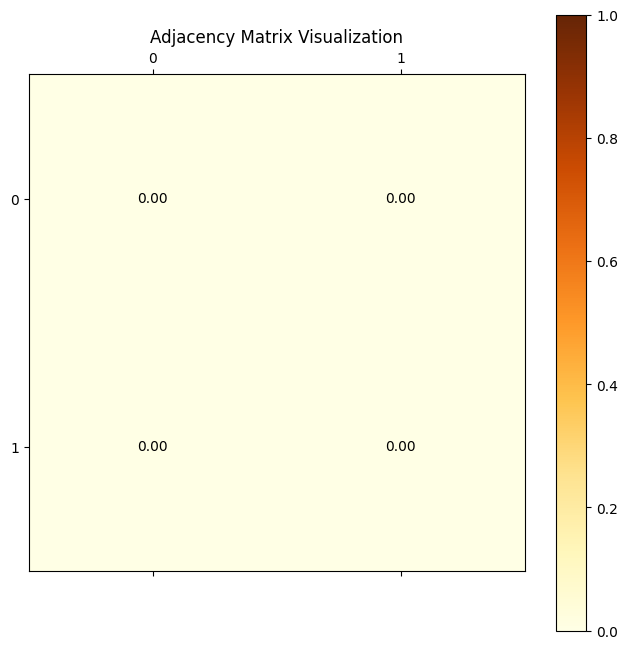

In [9]:
# adj_matrix = model.get_adjacency_matrix(threshold=False)
# print(adj_matrix)
import matplotlib.pyplot as plt
# Function to visualize adjacency matrix
def visualize_adjacency_matrix(adj_matrix):
    fig, ax = plt.subplots(figsize=(8, 8))
    vmin = np.min(adj_matrix)
    vmax = np.max(adj_matrix)
    if vmin==vmax:
        vmax=1.0 

    # Show matrix as a heatmap
    cax = ax.matshow(adj_matrix,vmin=vmin,vmax=vmax,cmap="YlOrBr")  # You can change cmap (e.g., "coolwarm", "viridis")

    # Add text annotations (show numbers in each cell)
    for i in range(adj_matrix.shape[0]):
        for j in range(adj_matrix.shape[1]):
            ax.text(j, i, f"{adj_matrix[i, j]:.2f}", ha='center', va='center', color='black')

    # Set labels
    ax.set_xticks(range(adj_matrix.shape[1]))
    ax.set_yticks(range(adj_matrix.shape[0]))
    ax.set_xticklabels(range(adj_matrix.shape[1]))
    ax.set_yticklabels(range(adj_matrix.shape[0]))

    # Set title and display the plot
    plt.colorbar(cax)
    plt.title("Adjacency Matrix Visualization")
    plt.show()

# Call the function
visualize_adjacency_matrix(np.array([[0,0],[0,0]]))

Is DAG: True


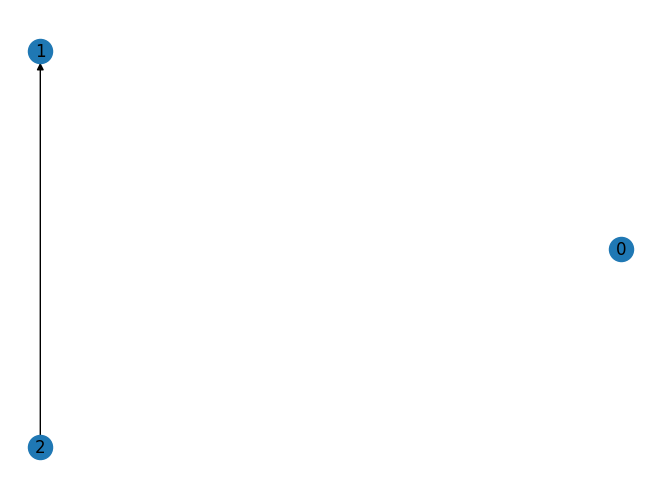

In [80]:
# We can visualize the graph with the networkx package (Note: you will need matplotlib for this step)
import networkx as nx
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph())
print('Is DAG:', nx.is_directed_acyclic_graph(G))
nx.draw_circular(G, with_labels=True)